# Disease Surveillance EDA
## 6 Years of Indian Health Data (2020-2025)

Exploratory Data Analysis after cleaning

## 1. SETUP & DATA LOADING

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [2]:
# Load data
df = pd.read_csv('data.csv')

print(f'Raw data shape: {df.shape}')
print(f'Rows: {len(df)}')
print(f'Columns: {list(df.columns)}')

Raw data shape: (7236, 9)
Rows: 7236
Columns: ['Unique_ID', 'State', 'District', 'Disease', 'Cases', 'Deaths', 'Year_Week', 'Month_Approx', 'disease_clean']


## 2. DATA CLEANING

In [3]:
# Check nulls before dropping
print('NULL VALUES BEFORE CLEANING:')
print(df.isnull().sum())
print(f'\nTotal rows: {len(df)}')

NULL VALUES BEFORE CLEANING:
Unique_ID        0
State            0
District         2
Disease          7
Cases            0
Deaths           0
Year_Week        0
Month_Approx     0
disease_clean    7
dtype: int64

Total rows: 7236


In [4]:
df.columns

Index(['Unique_ID', 'State', 'District', 'Disease', 'Cases', 'Deaths',
       'Year_Week', 'Month_Approx', 'disease_clean'],
      dtype='object')

In [5]:
# DROP ROWS WHERE Cases IS NULL (corrupted data)
print(f'Rows BEFORE dropna: {len(df)}')
df_clean = df.dropna(subset=['Cases']).copy()
print(f'Rows AFTER dropna (Cases): {len(df_clean)}')
print(f'Rows dropped: {len(df) - len(df_clean)}')

# Check remaining nulls
print(f'\nNULL VALUES AFTER CLEANING:')
print(df_clean.isnull().sum())

Rows BEFORE dropna: 7236
Rows AFTER dropna (Cases): 7236
Rows dropped: 0

NULL VALUES AFTER CLEANING:
Unique_ID        0
State            0
District         2
Disease          7
Cases            0
Deaths           0
Year_Week        0
Month_Approx     0
disease_clean    7
dtype: int64


## 3. BASIC STATISTICS

In [6]:
print('='*70)
print('DATASET OVERVIEW')
print('='*70)
print(f'Total rows: {len(df):,}')
print(f'Date range: {df["Year_Week"].min()} to {df["Year_Week"].max()}')
print(f'States: {df["State"].nunique()}')
print(f'Districts: {df["District"].nunique()}')
print(f'Diseases: {df["Disease"].nunique()}')

print(f'\nTotal Cases Reported: {df["Cases"].sum():,.0f}')
print(f'Total Deaths Reported: {df["Deaths"].sum():,.0f}')
print(f'CFR (Case Fatality Rate): {(df["Deaths"].sum() / df["Cases"].sum() * 100):.2f}%')

DATASET OVERVIEW
Total rows: 7,236
Date range: 2020-W02 to 2025-W52
States: 44
Districts: 616
Diseases: 50

Total Cases Reported: 229,872
Total Deaths Reported: 1,341
CFR (Case Fatality Rate): 0.58%


In [7]:
print('\nCASES STATISTICS:')
print(df['Cases'].describe())

print('\n\nDEATHS STATISTICS:')
print(df['Deaths'].describe())


CASES STATISTICS:
count    7236.000000
mean       31.767828
std        44.524573
min         0.000000
25%         9.000000
50%        18.000000
75%        36.000000
max       496.000000
Name: Cases, dtype: float64


DEATHS STATISTICS:
count    7236.000000
mean        0.185323
std         0.635125
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         9.000000
Name: Deaths, dtype: float64


## 4. DISEASE ANALYSIS

In [8]:
# Top diseases by case count
disease_cases = df.groupby('Disease')['Cases'].sum().sort_values(ascending=False)

print('TOP 15 DISEASES (by total cases):')
print('='*70)
for disease, cases in disease_cases.head(500).items():
    pct = (cases / df['Cases'].sum() * 100)
    print(f'{disease:40s} {cases:>10,.0f} ({pct:>5.1f}%)')

TOP 15 DISEASES (by total cases):
Acute Diarrheal Disease                      82,639 ( 36.0%)
Food Poisoning                               48,870 ( 21.3%)
Dengue                                       15,650 (  6.8%)
Hepatitis (A, B, E)                          15,615 (  6.8%)
Cholera                                      14,529 (  6.3%)
Chickenpox                                    8,152 (  3.5%)
Malaria                                       6,089 (  2.6%)
Mumps                                         6,082 (  2.6%)
Fever (Unspecified)                           5,770 (  2.5%)
Measles & Rubella                             5,264 (  2.3%)
Chikungunya                                   4,051 (  1.8%)
Acute Gastroenteritis                         3,846 (  1.7%)
Enteric Fever (Typhoid)                       2,912 (  1.3%)
Scrub Typhus                                  1,419 (  0.6%)
Fever with Rash                               1,393 (  0.6%)
Kyasanur Forest Disease                       1,148

In [9]:
# Top diseases by DEATHS
disease_deaths = df.groupby('Disease')['Deaths'].sum().sort_values(ascending=False)

print('TOP 15 DISEASES (by total deaths):')
print('='*70)
for disease, deaths in disease_deaths.head(15).items():
    pct = (deaths / df['Deaths'].sum() * 100)
    print(f'{disease:40s} {deaths:>10,.0f} ({pct:>5.1f}%)')

TOP 15 DISEASES (by total deaths):
Acute Diarrheal Disease                         323 ( 24.1%)
Rabies                                          137 ( 10.2%)
Dengue                                          131 (  9.8%)
Food Poisoning                                  115 (  8.6%)
Cholera                                          75 (  5.6%)
Acute Encephalitic Syndrome                      73 (  5.4%)
Malaria                                          70 (  5.2%)
Leptospirosis                                    55 (  4.1%)
Measles & Rubella                                52 (  3.9%)
Diphtheria                                       44 (  3.3%)
Fever (Unspecified)                              43 (  3.2%)
Hepatitis (A, B, E)                              41 (  3.1%)
Scrub Typhus                                     30 (  2.2%)
Japanese Encephalitis                            27 (  2.0%)
Mumps                                            15 (  1.1%)


In [10]:
# Diseases with highest CFR (Case Fatality Rate)
disease_cfr = df.groupby('Disease').agg({
    'Cases': 'sum',
    'Deaths': 'sum'
}).copy()
disease_cfr['CFR'] = (disease_cfr['Deaths'] / disease_cfr['Cases'] * 100)
disease_cfr = disease_cfr[disease_cfr['Cases'] >= 10]  # Min 10 cases
disease_cfr = disease_cfr.sort_values('CFR', ascending=False)

print('DISEASES WITH HIGHEST CFR (min 10 cases):')
print('='*70)
for disease, row in disease_cfr.head(10).iterrows():
    print(f'{disease:40s} CFR={row["CFR"]:>6.2f}% (Cases={row["Cases"]:>6.0f}, Deaths={row["Deaths"]:>4.0f})')

DISEASES WITH HIGHEST CFR (min 10 cases):
Rabies                                   CFR= 97.86% (Cases=   140, Deaths= 137)
Diphtheria                               CFR= 37.93% (Cases=   116, Deaths=  44)
Japanese Encephalitis                    CFR= 25.23% (Cases=   107, Deaths=  27)
Acute Encephalitic Syndrome              CFR= 20.86% (Cases=   350, Deaths=  73)
Epidemic Dropsy                          CFR= 20.00% (Cases=    40, Deaths=   8)
Animal Bites                             CFR= 13.25% (Cases=    83, Deaths=  11)
Anthrax                                  CFR= 11.63% (Cases=    43, Deaths=   5)
Mushroom Poisoning                       CFR=  7.69% (Cases=    91, Deaths=   7)
Leptospirosis                            CFR=  6.21% (Cases=   885, Deaths=  55)
Acute Febrile Illness                    CFR=  3.85% (Cases=    26, Deaths=   1)


## 5. GEOGRAPHIC ANALYSIS

In [11]:
# Top states by cases
state_cases = df.groupby('State')['Cases'].sum().sort_values(ascending=False)

print('TOP 15 STATES (by total cases):')
print('='*70)
for state, cases in state_cases.head(15).items():
    pct = (cases / df['Cases'].sum() * 100)
    print(f'{state:20s} {cases:>12,.0f} ({pct:>5.1f}%)')

TOP 15 STATES (by total cases):
Kerala                     35,295 ( 15.4%)
Karnataka                  22,079 (  9.6%)
Maharashtra                21,046 (  9.2%)
Madhya Pradesh             17,258 (  7.5%)
Gujarat                    14,711 (  6.4%)
Odisha                     13,994 (  6.1%)
Chhattisgarh               13,915 (  6.1%)
Assam                      11,619 (  5.1%)
West Bengal                 9,677 (  4.2%)
Tamil Nadu                  8,770 (  3.8%)
Jharkhand                   8,471 (  3.7%)
Andhra Pradesh              8,077 (  3.5%)
Jammu and Kashmir           7,515 (  3.3%)
Bihar                       5,933 (  2.6%)
Uttar Pradesh               5,931 (  2.6%)


In [12]:
# States with most reports (surveillance activity)
state_reports = df.groupby('State').size().sort_values(ascending=False)

print('TOP 15 STATES (by # of reports - surveillance infrastructure):')
print('='*70)
for state, count in state_reports.head(15).items():
    pct = (count / len(df) * 100)
    print(f'{state:20s} {count:>6} reports ({pct:>5.1f}%)')

TOP 15 STATES (by # of reports - surveillance infrastructure):
Kerala                  952 reports ( 13.2%)
Maharashtra             676 reports (  9.3%)
Madhya Pradesh          626 reports (  8.7%)
Karnataka               611 reports (  8.4%)
Assam                   561 reports (  7.8%)
Odisha                  463 reports (  6.4%)
Jharkhand               440 reports (  6.1%)
Tamil Nadu              399 reports (  5.5%)
Chhattisgarh            347 reports (  4.8%)
Gujarat                 332 reports (  4.6%)
Bihar                   274 reports (  3.8%)
Jammu and Kashmir       269 reports (  3.7%)
Uttar Pradesh           252 reports (  3.5%)
West Bengal             203 reports (  2.8%)
Andhra Pradesh          194 reports (  2.7%)


## 6. TEMPORAL ANALYSIS

In [13]:
# Cases by month (seasonal pattern)
month_cases = df.groupby('Month_Approx')['Cases'].agg(['sum', 'count', 'mean'])
month_cases.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                      'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print('CASES BY MONTH (6-year average):')
print('='*70)
print(month_cases)

CASES BY MONTH (6-year average):
       sum  count       mean
Jan  12524    357  35.081232
Feb  15028    505  29.758416
Mar  15163    484  31.328512
Apr  15136    453  33.412804
May  13503    507  26.633136
Jun  20382    559  36.461538
Jul  23653    748  31.621658
Aug  23898    740  32.294595
Sep  22353    710  31.483099
Oct  19815    642  30.864486
Nov  18117    572  31.673077
Dec  30300    959  31.595412


In [14]:
# Year-wise trend
df['Year'] = df['Year_Week'].str[:4].astype(int)
year_trend = df.groupby('Year').agg({
    'Cases': ['sum', 'count'],
    'Disease': 'nunique'
})
year_trend.columns = ['Total_Cases', 'Num_Reports', 'Unique_Diseases']

print('YEARLY TREND:')
print('='*70)
print(year_trend)
print(f'\nYear-over-year growth: {(year_trend.iloc[-1]["Total_Cases"] / year_trend.iloc[0]["Total_Cases"] - 1) * 100:.1f}%')

YEARLY TREND:
      Total_Cases  Num_Reports  Unique_Diseases
Year                                           
2020         6921          248               27
2021         7030          280               33
2022        21272          726               37
2023        49495         1545               36
2024        87815         2575               37
2025        57339         1862               34

Year-over-year growth: 728.5%


## 7. CORRELATION ANALYSIS

In [15]:
# Diseases that appear together (same week + state)
co_occurrence = df.groupby(['State', 'Year_Week'])['Disease'].nunique().describe()

print('DISEASE CO-OCCURRENCE (# diseases per state-week):')
print('='*70)
print(co_occurrence)
print(f'\nAvg diseases per state-week: {co_occurrence["mean"]:.2f}')
print(f'Max diseases in one state-week: {co_occurrence["max"]:.0f}')

DISEASE CO-OCCURRENCE (# diseases per state-week):
count    2824.000000
mean        1.847380
std         1.191126
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        11.000000
Name: Disease, dtype: float64

Avg diseases per state-week: 1.85
Max diseases in one state-week: 11


## 8. VISUALIZATIONS

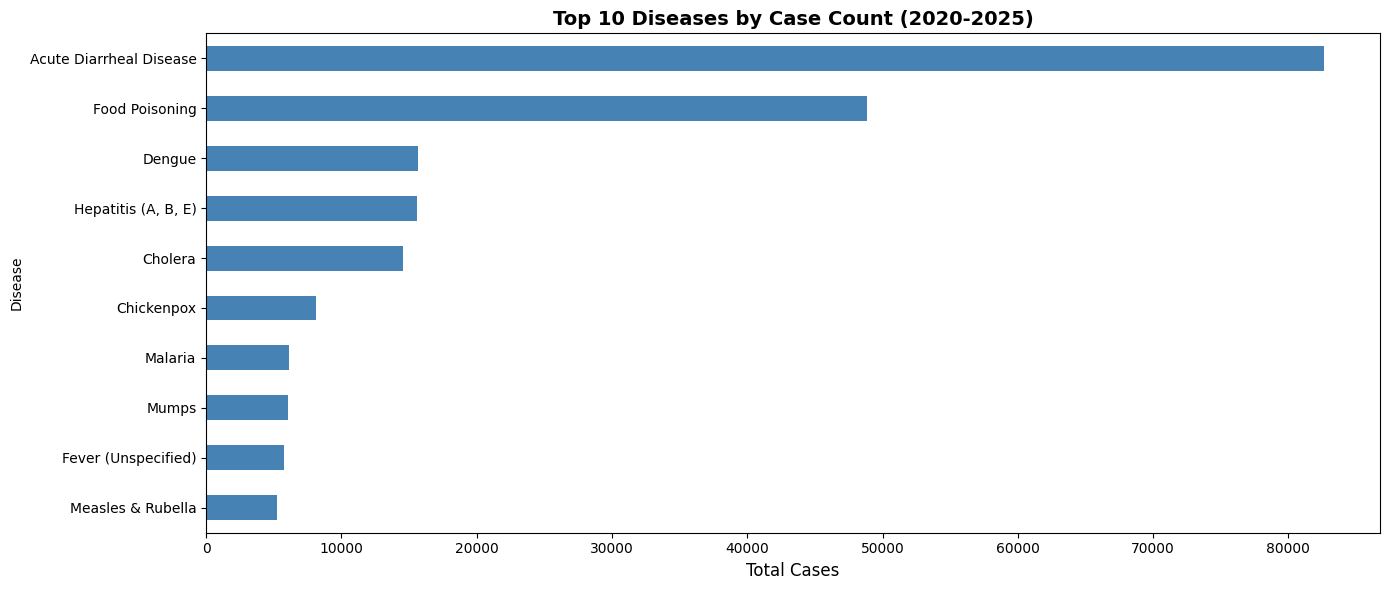

In [16]:
# Top 10 diseases
fig, ax = plt.subplots(figsize=(14, 6))
disease_cases.head(10).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Total Cases', fontsize=12)
ax.set_title('Top 10 Diseases by Case Count (2020-2025)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [17]:
# Get unmapped diseases


In [18]:
# ============================================
# FINAL COMPREHENSIVE DISEASE MAPPING
# Combines both mappings + fills all gaps
# ============================================

disease_mapping = {
    
    # ============================================
    # DIARRHEAL DISEASES (50% of your data)
    # ============================================
    'acute diarrheal disease': 'Acute Diarrheal Disease',
    'acute diarrhoeal disease': 'Acute Diarrheal Disease',
    'diarrheal disease': 'Acute Diarrheal Disease',
    'diarrheal disease acute': 'Acute Diarrheal Disease',
    'diarrheal disease food': 'Acute Diarrheal Disease',
    'diarrhoeal diarrhoea': 'Acute Diarrheal Disease',
    'diarrhoeal disease food': 'Acute Diarrheal Disease',
    'diarrhoeal disease suspected': 'Acute Diarrheal Disease',
    'disease acute diarrheal': 'Acute Diarrheal Disease',
    'diarrheal 26 00 ernakulam disease': 'Acute Diarrheal Disease',
    'diarrheal 41 00 06-04-21 burdhaman disease': 'Acute Diarrheal Disease',
    'diarrhoeal 98 00 29-01-20 haveli disease & nagar': 'Acute Diarrheal Disease',
    'nellore diarrheal 15 0 disease': 'Acute Diarrheal Disease',
    'satna diarrheal 8 2 disease': 'Acute Diarrheal Disease',
    'amritsar acute 16 2 diarrhoeal disease': 'Acute Diarrheal Disease',
    'diarrhoeal disease japanese': 'Acute Diarrheal Disease',
    
    # ============================================
    # GASTROENTERITIS
    # ============================================
    'acute gastroente ritis': 'Acute Gastroenteritis',
    'acute gastroenter itis': 'Acute Gastroenteritis',
    'acute gastroenteri tis': 'Acute Gastroenteritis',
    'acute gastroenteritis': 'Acute Gastroenteritis',
    'gastroenteritis': 'Acute Gastroenteritis',
    'gastroenteri tis': 'Acute Gastroenteritis',
    'enteritis acute': 'Acute Gastroenteritis',
    
    # Norovirus-specific
    'gastroenteritis (norovirus)': 'Viral/Respiratory',  # Your categorization
    'disease (norovirus) acute': 'Viral/Respiratory',
    'noro virus': 'Viral/Respiratory',
    'poisoning (norovirus) food': 'Viral/Respiratory',
    
    # ============================================
    # CHOLERA & DYSENTERY
    # ============================================
    'cholera': 'Cholera',
    'dysentery': 'Dysentery',
    'dysentry': 'Dysentery',
    'shigella': 'Shigellosis',
    'shigellosis': 'Shigellosis',
    '(shigella)': 'Shigellosis',
    '(shigella sonnie)': 'Shigellosis',
    'disease (shigella)': 'Shigellosis',
    'sonnei': 'Shigellosis',
    'disease (klebsiella)': 'Viral/Respiratory',  # Bacterial, grouped with respiratory
    
    # ============================================
    # ENCEPHALITIS & ACUTE ENCEPHALITIC SYNDROME
    # ============================================
    # Japanese Encephalitis (specific)
    'japanese encephalitis': 'Japanese Encephalitis',
    'encephalitis japanese': 'Japanese Encephalitis',
    'encephalitis disease/ japanese': 'Japanese Encephalitis',
    'encephalitic syndrome japanese': 'Japanese Encephalitis',
    
    # Acute Encephalitic Syndrome
    'acute encephalitic syndrome': 'Acute Encephalitic Syndrome',
    'encephalitic syndrome': 'Acute Encephalitic Syndrome',
    'encephalitic syndrome acute': 'Acute Encephalitic Syndrome',
    'encephalitis syndrome': 'Acute Encephalitic Syndrome',
    'encephalitis syndrome acute': 'Acute Encephalitic Syndrome',
    'encephalitis syndrome food': 'Acute Encephalitic Syndrome',
    
    # Specific causes of AES
    'acute encephalitic syndrome (suspected chpv)': 'Chandipura Virus',
    'chandipura virus': 'Chandipura Virus',
    'encephalitic syndrome scrub': 'Scrub Typhus',
    'encephalitic syndrome mushroom': 'Mushroom Poisoning',
    
    # Unspecified encephalitis
    'encephalitis': 'Acute Encephalitic Syndrome',  # Changed from "Unspecified" to match your grouping
    'encephalitis acute': 'Acute Encephalitic Syndrome',
    'encephalitis epidemic': 'Acute Encephalitic Syndrome',
    'encephalitis suspected': 'Acute Encephalitic Syndrome',
    'encephalitis suspected food': 'Acute Encephalitic Syndrome',
    'encephalitis food': 'Acute Encephalitic Syndrome',
    
    # Special encephalitis cases
    'phalitis (naegleria fowleri) acute': 'Meningitis',  # Primary Amoebic Meningoencephalitis
    
    # ============================================
    # MENINGITIS
    # ============================================
    'meningitis': 'Meningitis',
    
    # ============================================
    # VECTOR-BORNE DISEASES
    # ============================================
    'dengue': 'Dengue',
    'chikungunya': 'Chikungunya',
    'chikunguny a': 'Chikungunya',
    'chikungun ya': 'Chikungunya',
    'malaria': 'Malaria',
    '(plasmodiumfalciparum) kyasanur': 'Malaria',
    'zika': 'Zika Virus',
    'west nile': 'Viral/Respiratory',  # Grouped with viral illnesses
    'poisoning west nile': 'Viral/Respiratory',
    
    # Kyasanur Forest Disease
    'kyasanur forest disease': 'Kyasanur Forest Disease',
    'forest disease': 'Kyasanur Forest Disease',
    'kala azar kyasanur': 'Kyasanur Forest Disease',
    'poisoning kyasanur': 'Kyasanur Forest Disease',
    
    # Filariasis
    'filariasis': 'Filariasis',
    
    # ============================================
    # VISCERAL LEISHMANIASIS (Kala-azar)
    # ============================================
    'kala-azar': 'Visceral Leishmaniasis',
    'leishmaniasis': 'Visceral Leishmaniasis',
    'leishmaniasis (kala-azar)': 'Visceral Leishmaniasis',
    'leishmaniosis': 'Visceral Leishmaniasis',
    'poisoning visceral': 'Visceral Leishmaniasis',
    
    # ============================================
    # LEPTOSPIROSIS
    # ============================================
    'leptospirosis': 'Leptospirosis',
    'leptospiro sis': 'Leptospirosis',
    'leptospirosi s': 'Leptospirosis',
    
    # ============================================
    # SCRUB TYPHUS & TYPHUS
    # ============================================
    'scrub typhus': 'Scrub Typhus',
    'typhus scrub': 'Scrub Typhus',
    'typhus': 'Scrub Typhus',
    'typhus acute': 'Scrub Typhus',
    'typhus food': 'Scrub Typhus',
    'typhus japanese': 'Scrub Typhus',
    'poisoning scrub': 'Scrub Typhus',
    'poisoning japanese': 'Scrub Typhus',
    
    # ============================================
    # VIRAL HEMORRHAGIC FEVERS
    # ============================================
    'cchf': 'CCHF',
    'cchf acute': 'CCHF',
    'nipah virus': 'Nipah Virus',
    'nipah virus acute': 'Nipah Virus',
    
    # ============================================
    # CHICKENPOX
    # ============================================
    'chickenpox': 'Chickenpox',
    'chicken pox': 'Chickenpox',
    'chickenpo x': 'Chickenpox',
    'chikenpox': 'Chickenpox',
    'chicken pox food': 'Chickenpox',
    
    # ============================================
    # MONKEYPOX / MPOX
    # ============================================
    'mpox': 'Mpox (Monkeypox)',
    'mpox (clade i)': 'Mpox (Monkeypox)',
    'monkey pox': 'Mpox (Monkeypox)',
    'monkey pox acute': 'Mpox (Monkeypox)',
    'monkey pox food': 'Mpox (Monkeypox)',
    
    # ============================================
    # MEASLES & RUBELLA (Combined per your preference)
    # ============================================
    'measles': 'Measles & Rubella',
    'measles and rubella': 'Measles & Rubella',
    'rubella': 'Measles & Rubella',
    'rubella acute': 'Measles & Rubella',
    
    # ============================================
    # MUMPS
    # ============================================
    'mumps': 'Mumps',
    
    # ============================================
    # INFLUENZA & RESPIRATORY VIRUSES
    # ============================================
    'influenza': 'Viral/Respiratory',
    'influenza a': 'Viral/Respiratory',
    'h3n2 influenza a': 'Viral/Respiratory',
    'h3n2 acute': 'Viral/Respiratory',
    'swine flu (h1n1)': 'Viral/Respiratory',
    'like illness(ili)': 'Viral/Respiratory',
    'hmpv': 'Viral/Respiratory',
    'adeno virus': 'Viral/Respiratory',
    'urti': 'Viral/Respiratory',
    'respiratory illness acute': 'Viral/Respiratory',
    'respiratory illness suspected': 'Viral/Respiratory',
    'respiratory illness suspected food': 'Viral/Respiratory',
    
    # ============================================
    # HAND, FOOT, AND MOUTH DISEASE
    # ============================================
    'hand foot and mouth disease': 'Hand, Foot & Mouth Disease',
    'hand, foot and mouth disease': 'Hand, Foot & Mouth Disease',
    'hand, foot, and mouth disease (hfmd)': 'Hand, Foot & Mouth Disease',
    'hfmd': 'Hand, Foot & Mouth Disease',
    'disease (hfmd)': 'Hand, Foot & Mouth Disease',
    'suspected hfmd': 'Hand, Foot & Mouth Disease',
    'mouth disease': 'Hand, Foot & Mouth Disease',
    'mouth disease (hfmd)': 'Hand, Foot & Mouth Disease',
    'mouth disease acute': 'Hand, Foot & Mouth Disease',
    
    # ============================================
    # HEPATITIS (Combined A, B, E per your preference)
    # ============================================
    'hepatitis': 'Hepatitis (A, B, E)',
    'acute hepatitis': 'Hepatitis (A, B, E)',
    'hepatitis a': 'Hepatitis (A, B, E)',
    'hepatitis b': 'Hepatitis (A, B, E)',
    'hepatitis e': 'Hepatitis (A, B, E)',
    'hepatitis a & e': 'Hepatitis (A, B, E)',
    'a&e': 'Hepatitis (A, B, E)',
    '& e': 'Hepatitis (A, B, E)',
    'and e food': 'Hepatitis (A, B, E)',
    'b': 'Hepatitis (A, B, E)',
    'b suspected': 'Hepatitis (A, B, E)',
    'b&c': 'Hepatitis (A, B, E)',
    'jaundice': 'Hepatitis (A, B, E)',  # Often hepatitis-related
    
    # ============================================
    # ENTERIC FEVER (Typhoid/Paratyphoid)
    # ============================================
    'enteric fever': 'Enteric Fever (Typhoid)',
    'typhoid': 'Enteric Fever (Typhoid)',
    'suspected typhoid': 'Enteric Fever (Typhoid)',
    'paratyphoid': 'Enteric Fever (Typhoid)',
    
    # ============================================
    # FOOD POISONING
    # ============================================
    'food poisoning': 'Food Poisoning',
    'suspected food poisoning': 'Food Poisoning',
    'poisoning': 'Food Poisoning',
    'poisioning': 'Food Poisoning',
    'poisioning food': 'Food Poisoning',
    'poisoning food': 'Food Poisoning',
    'poisoning acute': 'Food Poisoning',
    'poisoning - illness': 'Food Poisoning',
    'poisoning - illness acute': 'Food Poisoning',
    'poisoning - illness food': 'Food Poisoning',
    'poisoning disease/ illness': 'Food Poisoning',
    'poisoning disease/ illness acute': 'Food Poisoning',
    'poisoning disease/ illness food': 'Food Poisoning',
    'poisoning disease/ illness japanese': 'Food Poisoning',
    'illness food borne': 'Food Poisoning',
    
    # Location-based poisoning entries (extract disease)
    'ajmer 32 00 22-02-20 poisoning acute': 'Food Poisoning',
    'bhandara 106 00 poisoning acute': 'Food Poisoning',
    'tiruvannamalai 09 00 20-02-20 poisoning acute': 'Food Poisoning',
    'medinapur west 425 00 19-02-20 poisoning': 'Food Poisoning',
    'nashik 40 0 poisoning': 'Food Poisoning',
    
    # ============================================
    # MUSHROOM POISONING (Separate category)
    # ============================================
    'mushroom poisoning': 'Mushroom Poisoning',
    'mushroom poisoning suspected': 'Mushroom Poisoning',
    'poisoning mushroom': 'Mushroom Poisoning',
    '(mushroom poisoning) acute': 'Mushroom Poisoning',
    '(mushroom poisoning) food': 'Mushroom Poisoning',
    
    # ============================================
    # CHEMICAL/OTHER POISONING
    # ============================================
    'rash chemical gas': 'Chemical/General Poisoning',
    'poisoning cutaneous': 'Chemical/General Poisoning',
    'poisoning viral': 'Chemical/General Poisoning',
    
    # ============================================
    # EPIDEMIC DROPSY
    # ============================================
    'dropsy': 'Epidemic Dropsy',
    'dropsy acute': 'Epidemic Dropsy',
    'epidemic dropsy acute': 'Epidemic Dropsy',
    
    # ============================================
    # ANIMAL BITES (Rabies risk + Snake)
    # ============================================
    'rabies': 'Rabies',
    'dog bite': 'Animal Bites',
    'dog bite acute': 'Animal Bites',
    'dog bite food': 'Animal Bites',
    'snake bite': 'Animal Bites',
    
    # ============================================
    # OTHER BACTERIAL INFECTIONS
    # ============================================
    'anthrax': 'Anthrax',
    'brucellosis': 'Brucellosis',
    'melioidosis': 'Melioidosis',
    'tetanus': 'Tetanus',
    'diphtheria': 'Diphtheria',
    'pertussis': 'Pertussis',
    'pertussis acute': 'Pertussis',
    'lymes disease': 'Lyme Disease',
    
    # ============================================
    # GENERIC/VAGUE SYMPTOMS
    # These we keep separate for "reporting bias" analysis
    # ============================================
    'fever': 'Fever (Unspecified)',
    'fever with rash': 'Fever with Rash',
    'rash': 'Rash (Unspecified)',
    'rash acute': 'Rash (Unspecified)',
    'rash food': 'Rash (Unspecified)',
    'rashes': 'Rash (Unspecified)',
    'rashes pyrexia of': 'Fever of Unknown Origin',
    'rohtas 05 00 rash': 'Rash (Unspecified)',
    
    'illness': 'Illness (Unspecified)',
    'illness acute': 'Illness (Unspecified)',
    'illness acute febrile': 'Acute Febrile Illness',
    
    'unknown origin': 'Fever of Unknown Origin',
    'unknown origin acute': 'Fever of Unknown Origin',
    'unknown origin food': 'Fever of Unknown Origin',
    'unknown origin pyrexia of': 'Fever of Unknown Origin',
    'of unknown cause': 'Fever of Unknown Origin',
    'indore unknown 35 0 origin': 'Fever of Unknown Origin',
    
    'paralysis': 'Acute Flaccid Paralysis',
    'virus & herpes virus 7) acute flaccid': 'Acute Flaccid Paralysis',
    
    # ============================================
    # MISCELLANEOUS / CATCH-ALL
    # ============================================
    'others': 'Other Disease',
    'others acute': 'Other Disease',
    '(suspected)': 'Disease (Suspected)',
    '4 weeks': 'Illness (Unspecified)',
    '7 days acute': 'Illness (Unspecified)',
    
}

# ============================================
# GARBAGE ENTRIES TO DROP
# Pure noise with no disease information
# ============================================
garbage_entries = [
    'health of personal illness. health and referral treatment. tab dham nagar, presented samples awaited.',
    'symptomatic tablets were regarding',
]

print(f"Total mappings defined: {len(disease_mapping)}")
print(f"Garbage entries to drop: {len(garbage_entries)}")

Total mappings defined: 214
Garbage entries to drop: 2


In [19]:


# Apply mapping
df['disease_clean'] = df['Disease'].str.lower().str.strip().map(disease_mapping)

# Drop garbage rows
df_clean = df[~df['Disease'].isin(garbage_entries)].copy()

# Check unmapped entries (should be very few)
unmapped = df_clean[df_clean['disease_clean'].isna()]['Disease'].value_counts()
print(f"Unmapped entries: {len(unmapped)}")
print(unmapped.head(20))

# Drop unmapped if negligible
df_final = df_clean.dropna(subset=['disease_clean'])

# Summary stats
print(f"\nOriginal rows: {len(df)}")
print(f"After dropping garbage: {len(df_clean)}")
print(f"Final clean dataset: {len(df_final)}")
print(f"\nUnique diseases before: {df['Disease'].nunique()}")
print(f"Unique diseases after: {df_final['disease_clean'].nunique()}")

# Top diseases
print("\nAll 50 diseases after cleaning:")
print(df_final['disease_clean'].value_counts().tail(50))

Unmapped entries: 20
Disease
Hepatitis (A, B, E)           547
Measles & Rubella             377
Fever (Unspecified)           218
Enteric Fever (Typhoid)       100
Rash (Unspecified)             53
Mpox (Monkeypox)               32
Zika Virus                     25
Viral/Respiratory              24
Animal Bites                   18
Fever of Unknown Origin        17
Visceral Leishmaniasis         10
Hand, Foot & Mouth Disease     10
Illness (Unspecified)           6
Acute Flaccid Paralysis         4
Other Disease                   3
Epidemic Dropsy                 3
Chemical/General Poisoning      3
Acute Febrile Illness           2
Disease (Suspected)             1
Lyme Disease                    1
Name: count, dtype: int64

Original rows: 7236
After dropping garbage: 7236
Final clean dataset: 5775

Unique diseases before: 50
Unique diseases after: 30

All 50 diseases after cleaning:
disease_clean
Acute Diarrheal Disease        2119
Food Poisoning                  984
Dengue          

In [20]:
# Check unique districts
districts = df_clean['District'].astype(str).str.strip().str.lower()

print("Unique districts:", districts.nunique())

# Top messy ones
print(districts.value_counts().tail(50))

Unique districts: 614
District
north goa                      1
garo hills                     1
faizabad                       1
institute, samples             1
mamit                          1
peddapalli disease district    1
leparada                       1
fatehabad                      1
jalandhar                      1
puducherry                     1
mahisagar, sabar kantha        1
khowai                         1
ghazipur                       1
mainpuri                       1
chhotaudepur                   1
belagavi bengaluru             1
ambagarh chouki                1
reasi                          1
namsai                         1
saitual                        1
siddharth nagar                1
bareilly                       1
sidhi disease district         1
dibang valley karbi-anglog     1
ratnagiri                      1
bankura                        1
kanchipuram                    1
noney                          1
lower subansiri                1
gondia      

In [21]:
import re

def extract_district_code(uid):
    try:
        return uid.split('/')[1]
    except:
        return None

df['District_Code'] = df['Unique_ID'].apply(extract_district_code)

print(df[['Unique_ID', 'District_Code']].head())

             Unique_ID District_Code
0  BH/JAH/2020/02/0020           JAH
1  JH/DHN/2020/02/0021           DHN
2  JH/ESI/2020/02/0022           ESI
3  KN/BGK/2020/02/0023           BGK
4  KL/PTH/2020/02/0033           PTH


In [22]:
district_codes = df['District_Code'].unique()

print("Unique district codes:", len(district_codes))
print(district_codes[:1500])

Unique district codes: 1058
['JAH' 'DHN' 'ESI' ... 'BEN' 'SEH' 'TUE']


In [23]:
# For each code, find most frequent district name
code_to_district = (
    df.groupby('District_Code')['District']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0])
)

# Convert to dict
code_to_district = code_to_district.to_dict()

# Apply mapping
df['District_Clean'] = df['District_Code'].map(code_to_district)

In [24]:
print(df[['District', 'District_Code', 'District_Clean']].head(20))

          District District_Code  District_Clean
0        Jehanabad           JAH       Jehanabad
1          Dhanbad           DHN         Dhanbad
2    East Singhbum           ESI   East Singhbum
3         Bagalkot           BGK        Bagalkot
4   Pathanamthitta           PTH  Pathanamthitta
5   Pathanamthitta           PTH  Pathanamthitta
6          Jhajjar           JJH         Jhajjar
7      Kurukshetra           KUK     Kurukshetra
8         Kolhapur           KOP        Kolhapur
9        Biswanath           SNT       Biswanath
10       Champaran           PAC       Champaran
11       Singhbhum           WSI       Singhbhum
12        Dhamtari           DHM        Dhamtari
13        Mahesana           MHS        Mahesana
14          Chatra           CHA          Chatra
15          Kannur           CNR          Kannur
16          Kannur           CNR          Kannur
17    Baloda Bazar           BBR    Baloda Bazar
18         Jhajjar           JJH         Jhajjar
19      Hazaribagh  

In [25]:
df['District_Clean'].nunique()

614

In [27]:
final_df = pd.read_csv("cleaned_data.csv")

In [29]:
print("DATA RETENTION %:", len(final_df)/len(df)*100)
print("UNIQUE DISEASES AFTER CLEAN:", final_df['Disease'].nunique())
print("UNIQUE DISTRICTS:", final_df['District'].nunique())
print("DUPLICATES:", final_df.duplicated().sum())

DATA RETENTION %: 100.0
UNIQUE DISEASES AFTER CLEAN: 50
UNIQUE DISTRICTS: 614
DUPLICATES: 0


In [30]:
final_df['Disease'].value_counts().head(15)

Disease
Acute Diarrheal Disease    2119
Food Poisoning              984
Hepatitis (A, B, E)         547
Dengue                      522
Chickenpox                  500
Measles & Rubella           377
Mumps                       302
Cholera                     251
Fever (Unspecified)         218
Malaria                     181
Chikungunya                 162
Rabies                      129
Fever with Rash             105
Enteric Fever (Typhoid)     100
Leptospirosis                96
Name: count, dtype: int64

In [31]:
final_df[final_df['Deaths'] >= 5]

,Unique_ID,State,District,Disease,Cases,Deaths,Year_Week,Month_Approx,disease_clean,Year
28,GJ/BNS/2020/05/0077,Gujarat,Banaskantha,Measles & Rubella,3,9,2020-W05,2,Measles & Rubella,2020
33,AS/KRG/2020/07/0116,Assam,Karimganj,Viral/Respiratory,8,6,2020-W07,2,Viral/Respiratory,2020
175,HR/MWT/2020/36/424,Haryana,Rupnagar,Diphtheria,27,8,2020-W36,9,Diphtheria,2020
247,MH/BED/2020/53/536,Maharashtra,Beed,Fever (Unspecified),15,7,2020-W53,12,Fever (Unspecified),2020
318,HP/KIR/2021/13/0156,Himachal Pradesh,Kochi Fortkochi,"Hepatitis (A, B, E)",2,7,2021-W13,4,"Hepatitis (A, B, E)",2021
355,GJ/SRT/2021/22/0205,Gujarat,Surat,Acute Diarrheal Disease,108,6,2021-W22,6,Acute Diarrheal Disease,2021
398,MH/BED/2021/28/0298,Maharashtra,Beed,Dysentery,13,6,2021-W28,7,Dysentery,2021
443,HR/PWL/2021/36/0439,Haryana,Palwal,Leptospirosis,8,8,2021-W36,9,Leptospirosis,2021
493,PB/PTL/2021/44/0611,Punjab,Patiala,Acute Diarrheal Disease,49,6,2021-W44,11,Acute Diarrheal Disease,2021
1548,JH/JAT/2023/18/368,Jharkhand,Jamtara,Rash (Unspecified),4,5,2023-W18,5,Rash (Unspecified),2023


In [34]:
import pkg_resources

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13636\1894539248.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


In [35]:
from ydata_profiling import ProfileReport
profile = ProfileReport(final_df, title="Disease Outbreak EDA Report", explorative=True)
profile.to_file("eda_report.html")

d:\Disease Outbreak\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Export report to file: 100%|██████████| 1/1 [00:00<00:00, 89.60it/s]
